<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [34]:
import pandas as pd
import numpy as np
import re

path = '/Users/lucasdubois/Desktop/MASTERDATA/' 

In [35]:
offwhite = (230/255, 230/255, 220/255)
midnight = (0/255, 22/255, 36/255)
steelblue = (171/255, 193/255, 223/255)
primaryred = (127/255, 20/255, 22/255)
harmonizedblue =(48/255,88/255,140/255)

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>1</small>&nbsp;&nbsp;&nbsp;&nbsp;Database:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">








<div style="text-align: align;">
  <h3> <small>1.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Extracting:</h3>
</div>

In order to realize this research, I will construct a database by combining several available databases. Firstly, I will start the database by adding the [WID](https://wid.world/)'s data for top income inequality as well as the top wealth . The [WID](https://wid.world/) provides data for both the 1st and the 10th percentiles, and will have both. This, hopefully, will allow us to obtain various results we can make sense of.

In [36]:
df1 = pd.read_csv(path + 'WID_income_inequality4.csv', sep=';', skiprows=1, engine='python')
df1.columns = df1.columns.str.strip()

def extract_country(col: str) -> str:
    parts = col.split("\n")
    return parts[-1].strip()

rename_map = {}
for col in df1.columns:
    if isinstance(col, str) and col.startswith("sptinc_z_"):
        rename_map[col] = extract_country(col) + "_inc"
    elif isinstance(col, str) and col.startswith("shweal_z_"):
        rename_map[col] = extract_country(col) + "_w"

df1 = df1.rename(columns=rename_map)

df_long = df1.melt(
    id_vars=['Percentile', 'Year'],
    var_name='CountryVar',
    value_name='Value'
)

tmp = df_long['CountryVar'].str.rsplit('_', n=1, expand=True)
df_long['Country Name'] = tmp[0]
df_long['kind'] = tmp[1]  

df_long = df_long[df_long['Percentile'].isin(['p99p100', 'p90p100'])]

pct_map = {'p99p100': 'top1', 'p90p100': 'top10'}
df_long['var'] = df_long['Percentile'].map(pct_map) + '_' + df_long['kind']

df1 = (df_long
           .pivot_table(index=['Year', 'Country Name'], columns='var', values='Value', aggfunc='mean')
           .reset_index()
           .sort_values(['Country Name', 'Year'])
           .reset_index(drop=True)
           .round(4))

df1.head()

var,Year,Country Name,top10_inc,top10_w,top1_inc,top1_w
0,1980,Afghanistan,0.4095,NaN,0.1583,NaN
1,1981,Afghanistan,0.4095,NaN,0.1583,NaN
2,1982,Afghanistan,0.4095,NaN,0.1583,NaN
3,1983,Afghanistan,0.4095,NaN,0.1583,NaN
4,1984,Afghanistan,0.4095,NaN,0.1583,NaN


In [37]:
df1.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/Final_WID.csv", index=False)

The paper by Roine et al., [2009](https://doi.org/10.1016/j.jpubeco.2009.04.003) provides several empirical insights regarding the long-run determinants of top-income inequality. Their approach (FDGLS and DFD) is nothing short of similar to ours, thus making their contribuition particularly interesting. I intend to add their results as controls in my endeavor, in order to add more information to the models and hopefuly improve it. Note nonetheless that the long-run nature of this project and the sample (mostly developed countries) might render some controls not significant or of magnitude in the model, but that we can only know when trying.
From their results, the authors find the following determinants to be statistically significant:

- Financial Development (total capitalization as a sum of bank deposits and market cap.)  (+)
- Income per capita (GDP per capita) (+)
- Marginal taxes (-)

We can then include several variables from the [World Bank Group](https://databank.worldbank.org) Databank in order to improve our model and reducing the chances of encountering endogeneity issues:

In [38]:
years = list(range(1995, 2024))

columns = ["Country Name", "Country Code", "Series Name", "Series Code"] + years

df_raw = pd.read_csv(
    path + 'World_Bank1.csv',
    sep=',',
    names=columns,
    engine='python',
    encoding='utf-8',
    skiprows=0,
    on_bad_lines='skip'
)

df_long = df_raw.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].astype(int)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")  

df_pivot = df_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "NW.DOW.PC.CD": "domestic_wealth_pc",
    "NW.NFA.PC.CD": "foreign_assets_pc",
    "NW.NFL.PC.CD": "foreign_liabilities_pc",
    "NW.HCA.PC.CD": "human_capital_pc",
    "NW.TOW.TO.CD": "national_wealth_total",
    "NW.DOW.TO.CD": "domestic_wealth_total"
})

df_pivot = df_pivot.sort_values(["Country Name", "Year"]).reset_index(drop=True)

df2 = df_pivot.round(2)

df2.head()


Series Code,Country Name,Year,domestic_wealth_pc,domestic_wealth_total,human_capital_pc,foreign_assets_pc,foreign_liabilities_pc,national_wealth_total
0,Albania,1995,10150.35,3.235712e+10,4257.13,163.44,194.81,3.225712e+10
1,Albania,1996,12135.21,3.844475e+10,4950.64,208.96,231.69,3.837275e+10
2,Albania,1997,10135.05,3.190797e+10,3446.47,195.34,250.30,3.173497e+10
3,Albania,1998,11211.24,3.507471e+10,3739.96,249.00,310.69,3.488171e+10
4,Albania,1999,12807.14,3.981456e+10,4502.05,315.56,372.82,3.963656e+10


In [39]:
df2.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/Final_WB1.csv", index=False)

In [40]:
file = path + "World_Bank2.csv"

with open(file, "r", encoding="utf-8") as f:
    lines = f.readlines()

header_row = None
for i, line in enumerate(lines[:50]): 
    if "Country Name" in line and "Country Code" in line:
        header_row = i
        break

if header_row is None:
    header_row = 0

df_raw1 = pd.read_csv(
    file,
    sep=",",                
    header=header_row,       
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip"
)

df_raw1.columns = df_raw1.columns.astype(str).str.strip()

rename_meta = {
    "Indicator Name": "Series Name",
    "Indicator Code": "Series Code"
}
df_raw1 = df_raw1.rename(columns=rename_meta)

required = ["Country Name", "Country Code", "Series Name", "Series Code"]
missing = [c for c in required if c not in df_raw1.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. "
                     f"Available columns: {list(df_raw1.columns)}")

def is_year(col):
    col = str(col)
    return bool(re.fullmatch(r"\d{4}", col)) or bool(re.fullmatch(r"\d{4}\s*\[YR\d{4}\]", col))

year_cols = [c for c in df_raw1.columns if is_year(c)]

year_rename = {}
for c in year_cols:
    m = re.search(r"(\d{4})", str(c))
    if m:
        year_rename[c] = m.group(1)
if year_rename:
    df_raw1 = df_raw1.rename(columns=year_rename)
    year_cols = [year_rename.get(c, c) for c in year_cols]  # normalized

df_long1 = df_raw1.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long1["Year"] = pd.to_numeric(df_long1["Year"], errors="coerce").astype("Int64")
df_long1["Value"] = pd.to_numeric(df_long1["Value"], errors="coerce")

df_long1 = df_long1.dropna(subset=["Year"]).astype({"Year": "int64"})

df_3 = df_long1.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value",
    aggfunc="mean"  
).reset_index()

df_3 = df_3.rename(columns={
    "NY.GDP.PCAP.CD": "gdp_per_cap",
    "HD.HCI.OVRL": "human_capital_index",
    "FP.CPI.TOTL.ZG": "inflation",
    "FR.INR.LNDP": "interest_rate_pct_rev",  
    "GC.XPN.INTP.RV.ZS": "interest_rate_spread",
    "SE.SEC.CUAT.LO.MA.ZS": "educational_attainment",
    "SL.UEM.TOTL.NE.ZS": "unemployment"
})

df_3 = df_3.sort_values(["Country Name", "Year"]).reset_index(drop=True)
df3 = df_3.round(2)

print(df_3.head())
print(df_3.columns.tolist()[:12])

Series Code Country Name  Year  inflation  interest_rate_pct_rev  \
0            Afghanistan  1975        NaN                    NaN   
1            Afghanistan  1979        NaN                    NaN   
2            Afghanistan  2000        NaN                    NaN   
3            Afghanistan  2001        NaN                    NaN   
4            Afghanistan  2002        NaN                    NaN   

Series Code  interest_rate_spread  human_capital_index  gdp_per_cap  \
0                             NaN                  NaN          NaN   
1                             NaN                  NaN          NaN   
2                             NaN                  NaN   174.930991   
3                             NaN                  NaN   138.706822   
4                             NaN                  NaN   178.954088   

Series Code  educational_attainment  unemployment  
0                              6.31           NaN  
1                              7.45           NaN  
2       

In [41]:
df3.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/Final_WB2.csv", index=False)

I will include the Gini for the countries as a potential robustness measure.

For this I use Solt ([2019](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/LM4OWF)) SWIID database

In [42]:
df4 = pd.read_csv(
    path + "swiid.csv",
    sep=",",                
    header=header_row,       
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip"
)

In [43]:
df4 = df4.rename(columns ={
    'country' : 'Country Name',
    'year' : 'Year'})

In [44]:
df5 = pd.read_excel(
    path + "Penn.xlsx", 
    sheet_name="Data")

In [45]:
df5 = df5.rename(columns ={
    'country' : 'Country Name',
    'year' : 'Year'})

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">


<div style="text-align: align;">
  <h3> <small>1.2</small>&nbsp;&nbsp;&nbsp;&nbsp;Merging:</h3>
</div>

Now we need to merge our four datasets in order to have a final workable dataset in which we can work.

In [46]:
merged1 = pd.merge(df1, df2, on=["Country Name", "Year"], how="outer")
merged2 = pd.merge(merged1, df3, on=["Country Name", "Year"], how="outer")
merged3 = pd.merge(merged2, df4, on=["Country Name", "Year"], how="outer")
merged4 =  pd.merge(merged3, df5, on=["Country Name", "Year"], how="outer")


In [47]:
MASTER_FINAL_RAW = merged4

MASTER_FINAL_RAW= MASTER_FINAL_RAW.sort_values(["Country Name", "Year"]).reset_index(drop=True)
MASTER_FINAL_RAW = MASTER_FINAL_RAW.round(4)

print(MASTER_FINAL_RAW.shape)
MASTER_FINAL_RAW.head()

(21503, 76)


,Year,Country Name,top10_inc,top10_w,top1_inc,top1_w,domestic_wealth_pc,domestic_wealth_total,human_capital_pc,foreign_assets_pc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,1975,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1979,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1980,Afghanistan,0.4095,NaN,0.1583,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1981,Afghanistan,0.4095,NaN,0.1583,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1982,Afghanistan,0.4095,NaN,0.1583,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now, that we've merged our three databases in order to create a final one, we have a total of 17 variables, for each year and country, namely:

- _top10_inc_: Pre-tax national income share of the 10% top income earners.
- _top1_inc_: Pre-tax national income share of the 1% top income earners.
- _top10_w_: Net personal wealth of equally split adults, top 10%.
- _top10_w_: Net personal wealth of equally split adults, top 10%.
- _domestic_wealth_pc_: Domestic comprehensive wealth index.
- _domestic_wealth_total_: Domestic comprehensive wealth index per capita.
- _human_capital_pc_: Human capital per capita
- _foreign_assets_pc_: Foreign assets per capita.
- _foreign_liabilities_pc_: Foreign liabilities per capita.
- _national_wealth_total_: National comprehensive wealth.
- _inflation_: Annual GDP deflator in %.
- _interest_rate_pct_rev_: Interest rates as a percentage of revenue.
- _interest_rate_spread_: Interest rate spread.
- _human_capital_index_: Human capital Index
- _gdp_per_cap_: GDP per capita.
- _educational_attainment_: School enrollment, secondary.
- _unemployment_: Total unemployment.


In [48]:
MASTER_FINAL_RAW.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/MASTER_FINAL_RAW.csv", index=False)

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">


<div style="text-align: align;">
  <h3> <small>1.3</small>&nbsp;&nbsp;&nbsp;&nbsp;Cleaning Data:</h3>
</div>

In [49]:
df = pd.read_csv("/Users/lucasdubois/Desktop/MASTERDATA/MASTER_FINAL_RAW.csv")
n_obs = len(df)
n_obs = df.shape[0]

print("Number of observations:", n_obs)

Number of observations: 21503


The year 2024 contains essentially NA's, so we will simply drop it out of the database:

In [50]:
df = df[df['Year'] != 2024]

Some countries have a mismatch between databases (e.g. USA and United States). We need to fix those before cleaning the data:

In [51]:
df["Country Name"] = df["Country Name"].replace({
    "USA": "United States"
})

df["Country Name"] =df["Country Name"].replace({
    "Bahamas, The": "Bahamas"
})

df["Country Name"] =df["Country Name"].replace({
    "Iran, Islamic Rep.": "Iran"
})

df["Country Name"] =df["Country Name"].replace({
    "Egypt, Arab Rep.": "Egypt"
})

df["Country Name"] =df["Country Name"].replace({
    "Hong Kong SAR, China": "Hong Kong"
})

df["Country Name"] =df["Country Name"].replace({
    "Korea, Rep.": "Korea"
})

df["Country Name"] =df["Country Name"].replace({
    "Turkiye": "Turkey"
})

df["Country Name"] =df["Country Name"].replace({
    "Yemen, Rep": "Yemen"
})

df["Country Name"] =df["Country Name"].replace({
    "Congo, Rep": "DR Congo"
})


df = df.groupby(["Country Name", "Year"], as_index=False).mean(numeric_only=True)
us_data = df[df["Country Name"] == "United States"]
print(us_data)



        Country Name  Year  top10_inc  top10_w  top1_inc  top1_w  \
19770  United States  1820     0.4200      NaN    0.1600     NaN   
19771  United States  1850     0.4500      NaN    0.1700     NaN   
19772  United States  1880     0.3770      NaN    0.1170     NaN   
19773  United States  1900     0.3980      NaN    0.1550     NaN   
19774  United States  1910     0.4312      NaN    0.2043     NaN   
...              ...   ...        ...      ...       ...     ...   
19881  United States  2019     0.4567   0.7141    0.1904  0.3485   
19882  United States  2020     0.4461   0.7103    0.1817  0.3513   
19883  United States  2021     0.4607   0.7085    0.1988  0.3626   
19884  United States  2022     0.4686   0.6962    0.2073  0.3489   
19885  United States  2023     0.4676   0.6958    0.2073  0.3483   

       domestic_wealth_pc  domestic_wealth_total  human_capital_pc  \
19770                 NaN                    NaN               NaN   
19771                 NaN                  

In [52]:
usa_data = df[df["Country Name"] == "USA"]
print(usa_data)

Empty DataFrame
Columns: [Country Name, Year, top10_inc, top10_w, top1_inc, top1_w, domestic_wealth_pc, domestic_wealth_total, human_capital_pc, foreign_assets_pc, foreign_liabilities_pc, national_wealth_total, inflation, interest_rate_pct_rev, interest_rate_spread, human_capital_index, gdp_per_cap, educational_attainment, unemployment, gini_disp, gini_disp_se, gini_mkt, gini_mkt_se, abs_red, abs_red_se, rel_red, rel_red_se, rgdpe, rgdpo, pop, emp, avh, hc, ccon, cda, cgdpe, cgdpo, cn, ck, ctfp, cwtfp, rgdpna, rconna, rdana, rnna, rkna, rtfpna, rwtfpna, labsh, irr, delta, xr, pl_con, pl_da, pl_gdpo, cor_exp, csh_c, csh_i, csh_g, csh_x, csh_m, csh_r, pl_c, pl_i, pl_g, pl_x, pl_m, pl_n, pl_k]
Index: []

[0 rows x 69 columns]


In [53]:
countries = df["Country Name"].unique()
print(countries)


<StringArray>
[                'Afghanistan', 'Africa Eastern and Southern',
  'Africa Western and Central',                     'Albania',
                     'Algeria',              'American Samoa',
                     'Andorra',                      'Angola',
                    'Anguilla',         'Antigua and Barbuda',
 ...
                    'Viet Nam',                     'Vietnam',
       'Virgin Islands (U.S.)',          'West Bank and Gaza',
                       'World',                       'Yemen',
                 'Yemen, Rep.',                  'Yugoslavia',
                      'Zambia',                    'Zimbabwe']
Length: 318, dtype: str


In [54]:
countries_to_drop = ["Arab World", "'Bahamas, The", "Bahrain","Bonaire, Sint Eustatius and Saba","British Virgin Islands'","Brunei Darussalam",
                     "Caribbean small states","Central Europe and the Baltics","Early-demographic dividend","East Asia & Pacific",
                     "East Asia & Pacific (IDA & IBRD countries)","East Asia & Pacific (excluding high income)","Euro area","Europe & Central Asia",
                     "Europe & Central Asia (IDA & IBRD countries)","Europe & Central Asia (excluding high income)","European Union",
                     "Fragile and conflict affected situations","Gambia, The", "Gambia","German Democratic Republic","Heavily indebted poor countries (HIPC)",
                     "High income", "IBRD only","IDA & IBRD total","IDA blend","IDA only","IDA total","Lao PDR","Late-demographic dividend",
                     "Latin America & Caribbean","Latin America & Caribbean (excluding high income)","Latin America & the Caribbean (IDA & IBRD countries)",
                     "Least developed countries: UN classification","Low & middle income","Low income","Lower middle income","Micronesia","Micronesia, Fed. Sts.",
                     "Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",
                     "Middle East, North Africa, Afghanistan & Pakistan (excluding high income)","Middle income","Montserrat","OECD members",
                     "Other small states","Pacific island small states","Post-demographic dividend","Pre-demographic dividend","Saint Kitts and Nevis",
                     "Sint Maarten (Dutch part)","Small states","South Asia","South Asia (IDA & IBRD)","St. Kitts and Nevis", "St. Martin (French part)",
                     "Sub-Saharan Africa","Sub-Saharan Africa (IDA & IBRD countries)","Sub-Saharan Africa (excluding high income)","Swaziland","Upper middle income",
                     "Virgin Islands (U.S.)","World"
                    ]

df = df[~df["Country Name"].isin(countries_to_drop)]

In [55]:
df.to_csv(path + "scm_usa.csv", index=False)

In [56]:
eligible_countries = (
    df.loc[(df["Year"] <= 1985) & (df["top1_inc"].notna()), "Country Name"]
    .unique()
)

df = df[df["Country Name"].isin(eligible_countries)]

In [57]:
countries = df["Country Name"].unique()
print(countries)
len(countries)

<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
             'Andorra',              'Angola',            'Anguilla',
 'Antigua and Barbuda',           'Argentina',             'Armenia',
               'Aruba',
 ...
      'United Kingdom',       'United States',             'Uruguay',
          'Uzbekistan',             'Vanuatu',           'Venezuela',
            'Viet Nam',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 206, dtype: str


206

In [58]:
df = df[df["Year"] >= 1985]


In [59]:
countries_with_missing = df.loc[
    df[["inflation", "gdp_per_cap"]].isna().any(axis=1), "Country Name"
].unique()

df= df[~df["Country Name"].isin(countries_with_missing)]

In [60]:
countries = df["Country Name"].unique()
print(countries)
len(countries)

<StringArray>
[                 'Algeria',                'Australia',
                  'Austria',                  'Bahamas',
                  'Belgium',                   'Belize',
                   'Bhutan',                  'Bolivia',
                 'Botswana',                   'Brazil',
             'Burkina Faso',                  'Burundi',
               'Cabo Verde',                 'Cameroon',
                   'Canada', 'Central African Republic',
                     'Chad',                    'Chile',
                 'Colombia',                   'Cyprus',
                  'Denmark',                 'Dominica',
       'Dominican Republic',                  'Ecuador',
                    'Egypt',              'El Salvador',
                     'Fiji',                  'Finland',
                   'France',                    'Gabon',
                  'Germany',                    'Ghana',
                   'Greece',                  'Grenada',
                '

94

In [61]:
df.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/MASTER_FINAL(0).csv", index=False)

- For Brazil, we have a special problem: estimates for 1995 below are stagnated at a soil, which would make this whole project impossible. Thankfully, the working paper by Dr. Marc Morgan gives new estimates we can use.

In [62]:
brazil_top1 = {
    1980: 0.2246,
    1981: 0.2125,
    1982: 0.2249,
    1983: 0.2143,
    1984: 0.2418,
    1985: 0.2697,
    1986: 0.2364,
    1987: 0.2548,
    1988: 0.2595,
    1989: 0.2838,
    1990: 0.2531,
    1991: 0.2477,
    1992: 0.2424,
    1993: 0.2548,
    1994: 0.2674,
    1995: 0.1903,
    1996: 0.1916,
    1997: 0.1880,
    1998: 0.1929,
    1999: 0.18622,
    2000: 0.1980,
    2001: 0.2113,
    2002: 0.2068,
    2003: 0.2006,
    2004: 0.2166,
    2005: 0.2363,
    2006: 0.2331,
    2007: 0.2371,
    2008: 0.2592,
    2009: 0.2285,
    2010: 0.2419,
    2011: 0.2566,
    2012: 0.2372,
    2013: 0.2412,
    2014: 0.2462,
    2015: 0.2526
}

In [63]:
for year, value in brazil_top1.items():
    mask = (df["Country Name"] == "Brazil") & (df["Year"] == year)
    df.loc[mask, "top1_inc"] = value


At least, let us eliminate the remaining countries that also have stagnated estimates below 1995

In [64]:
comparison = df[df['Year'].isin([1994, 1995])].pivot(index='Country Name', columns='Year', values='top1_inc')

countries_to_drop = comparison[comparison[1994] == comparison[1995]].index.tolist()

print("Countries to drop:", countries_to_drop)

df = df[~df['Country Name'].isin(countries_to_drop)]

Countries to drop: ['Algeria', 'Bahamas', 'Belize', 'Bhutan', 'Bolivia', 'Burundi', 'Cabo Verde', 'Cameroon', 'Chad', 'Chile', 'Colombia', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Gabon', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Kuwait', 'Libya', 'Malawi', 'Malta', 'Mauritius', 'Mexico', 'Morocco', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Qatar', 'Saudi Arabia', 'Senegal', 'Seychelles', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Uruguay']


In [65]:
countries = df["Country Name"].unique()
print(countries)
len(countries)

<StringArray>
[               'Australia',                  'Austria',
                  'Belgium',                 'Botswana',
                   'Brazil',             'Burkina Faso',
                   'Canada', 'Central African Republic',
                   'Cyprus',                  'Denmark',
                 'Dominica',                    'Egypt',
                     'Fiji',                  'Finland',
                   'France',                  'Germany',
                    'Ghana',                   'Greece',
                  'Grenada',                'Hong Kong',
                  'Hungary',                  'Iceland',
                    'India',                     'Iran',
                  'Ireland',                   'Israel',
                    'Italy',                    'Japan',
                    'Kenya',                    'Korea',
               'Luxembourg',               'Madagascar',
                 'Malaysia',                    'Nepal',
              'Ne

56

In [66]:
df.to_csv("/Users/lucasdubois/Desktop/MASTERDATA/MASTER_FINAL.csv", index=False)

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">


<div style="text-align: align;">
  <h3> <small>1.4</small>&nbsp;&nbsp;&nbsp;&nbsp;Descriptive Statistics:</h3>
</div>

In [39]:
cols = [
    "top1_inc", "top10_inc", "inflation", "gdp_per_cap",
    "unemployment", "human_capital_index",
    "interest_rate_pct_rev", 
]

In [40]:
for col in cols:
    print(col, df[col].mean())

top1_inc 0.14058190476190477
top10_inc 0.4110378335949764
inflation 11.244071428571427
gdp_per_cap 21821.751693877555
unemployment 7.304261857047428
human_capital_index 0.6614044943820224
interest_rate_pct_rev 5.329942263279446


In [41]:
for col in cols:
    print(col, df[col].var())

top1_inc 0.0024469515385689357
top10_inc 0.00938480675111575
inflation 10409.524394032673
gdp_per_cap 553599375.9810382
unemployment 25.034194391278096
human_capital_index 0.022759033200025397
interest_rate_pct_rev 42.68472936082446


In [42]:
for col in cols:
    print(col, df[col].median())

top1_inc 0.1266
top10_inc 0.3917
inflation 3.14
gdp_per_cap 13908.735
unemployment 6.06
human_capital_index 0.74
interest_rate_pct_rev 4.11


In [43]:
year_means = (
    df.groupby("Year")[cols]
      .mean()
      .sort_values(by="top1_inc", ascending=False)
      .round(3)
)
print(year_means)

      top1_inc  top10_inc  inflation  gdp_per_cap  unemployment  \
Year                                                              
2005     0.154      0.427      4.178    22866.263         6.846   
2006     0.154      0.427      4.039    24331.913         6.602   
2007     0.153      0.427      4.034    27733.253         5.884   
2004     0.152      0.424      3.891    21468.865         7.107   
2008     0.150      0.422      7.659    29764.312         5.894   
2003     0.148      0.422      3.882    18781.528         7.490   
2002     0.147      0.420      3.535    15897.163         7.159   
2010     0.146      0.419      3.677    27982.293         7.796   
2001     0.146      0.419      4.734    14878.825         6.561   
2011     0.146      0.419      5.092    30741.323         7.419   
2000     0.146      0.418      4.175    15073.659         7.151   
1999     0.144      0.416      2.771    15412.372         7.810   
2021     0.144      0.417      4.465    34804.723         7.47

In [47]:
mpl.rcParams.update({
    "font.size": 11,               
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titlesize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "text.usetex": False,        
})

In [48]:
df["top1_pct_change"] = df.groupby("Country Name")["top1_inc"].pct_change() * 100

In [49]:

brazil = (
    df_malka[df_malka["Country Name"] == "Brazil"]
    .set_index("Year")["top1_inc"]
    .sort_index()
)

# Split
brazil_pre  = brazil.loc[brazil.index <= 1995]
brazil_post = brazil.loc[brazil.index > 1995]

def fit_line(series):
    years = series.index.to_numpy()
    y = series.to_numpy()
    X = np.column_stack([np.ones(len(years)), years])  # [1, Year]
    beta = np.linalg.lstsq(X, y, rcond=None)[0]        # y = b0 + b1*Year
    yhat = X @ beta
    return years, yhat, beta

years_pre,  yhat_pre,  beta_pre  = fit_line(brazil_pre)
years_post, yhat_post, beta_post = fit_line(brazil_post)

print("Pre-1995 beta (intercept, slope):", beta_pre)
print("Post-1995 beta (intercept, slope):", beta_post)

NameError: name 'df_malka' is not defined

In [50]:
fig, ax = plt.subplots(figsize=(10, 5.6))

ax.plot(world_mean.index, world_mean.values, marker='x', label='World Mean', color=primaryred, linewidth=2)
ax.plot(belgium_data.index, belgium_data.values, marker='^', label='Belgium', linestyle='--', color=harmonizedblue, linewidth=2)

# Brazil actual + fitted lines
ax.plot(brazil.index, brazil.values, label="Brazil (actual)", linewidth=2)
ax.plot(years_pre,  yhat_pre,  label="Brazil fit ≤1995", linestyle="--", linewidth=2,color="black")
ax.plot(years_post, yhat_post, label="Brazil fit >1995", linestyle="--", linewidth=2,color="black")

plt.axvline(2003, color="red", linestyle=":", alpha=0.5)
plt.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

ax.set_xlabel('Year')
ax.set_ylabel('Top 1% Income')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.patch.set_facecolor(offwhite)
ax.set_facecolor(offwhite)

fig.savefig("/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/top1inc_comp.png", bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

NameError: name 'plt' is not defined

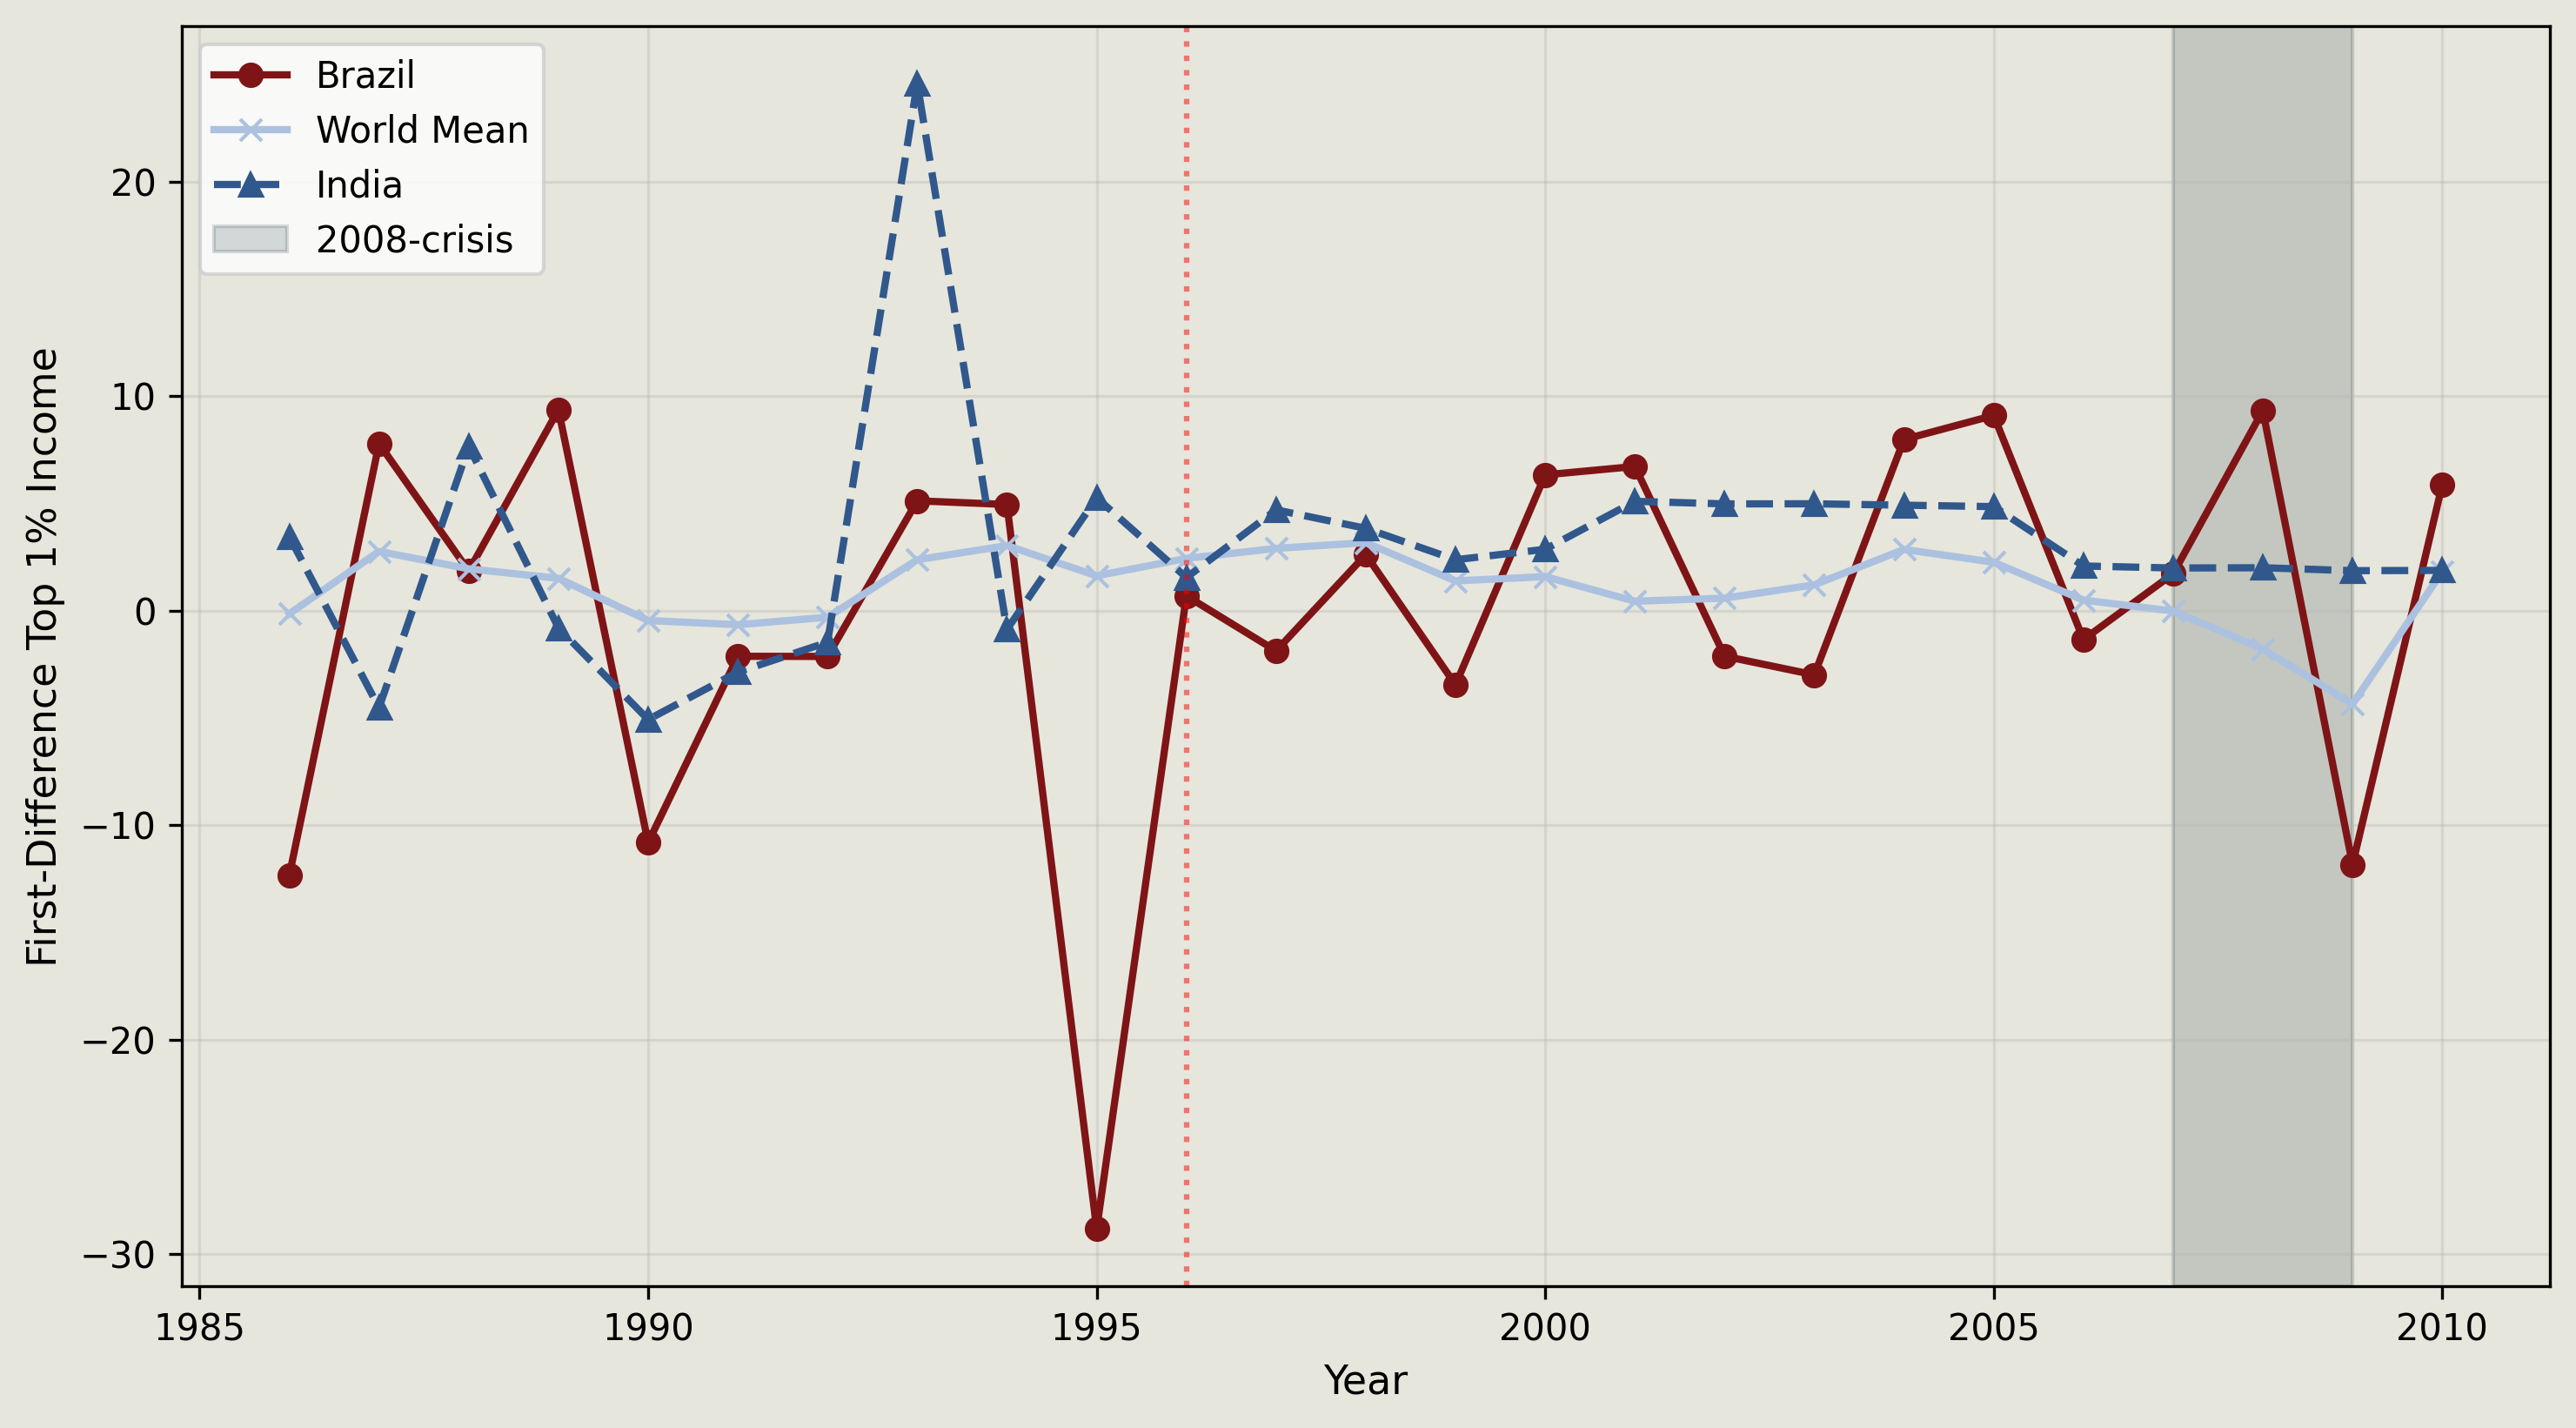

In [89]:
years = list(range(1985, 2015))

df_malka= df[(df['Year'] >= 1980) & (df['Year'] <= 2010)]
world_mean = df_malka.groupby('Year')['top1_pct_change'].mean()
world_median = df_malka.groupby('Year')['top1_pct_change'].median()
brazil_data = df_malka[df_malka['Country Name'] == 'Brazil'].set_index('Year')['top1_pct_change']
belgium_data = df_malka[df_malka['Country Name'] == 'Belgium'].set_index('Year')['top1_pct_change']
india_data = df_malka[df_malka['Country Name'] == 'India'].set_index('Year')['top1_pct_change']

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(brazil_data.index, brazil_data.values, marker='o', label='Brazil', color= primaryred, linewidth=2)
ax.plot(world_mean.index, world_mean.values, marker='x', label='World Mean', color=steelblue, linewidth=2)
ax.plot(belgium_data.index, india_data.values, marker='^', label='India', linestyle='--', color=harmonizedblue, linewidth=2)

plt.axvline(1996, color="red", linestyle=":",alpha=0.5)
plt.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

ax.set_xlabel('Year')
ax.set_ylabel('First-Difference Top 1% Income')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor(offwhite) 
ax.set_facecolor(offwhite) 

fig.savefig("/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/lntop1inc.png", bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

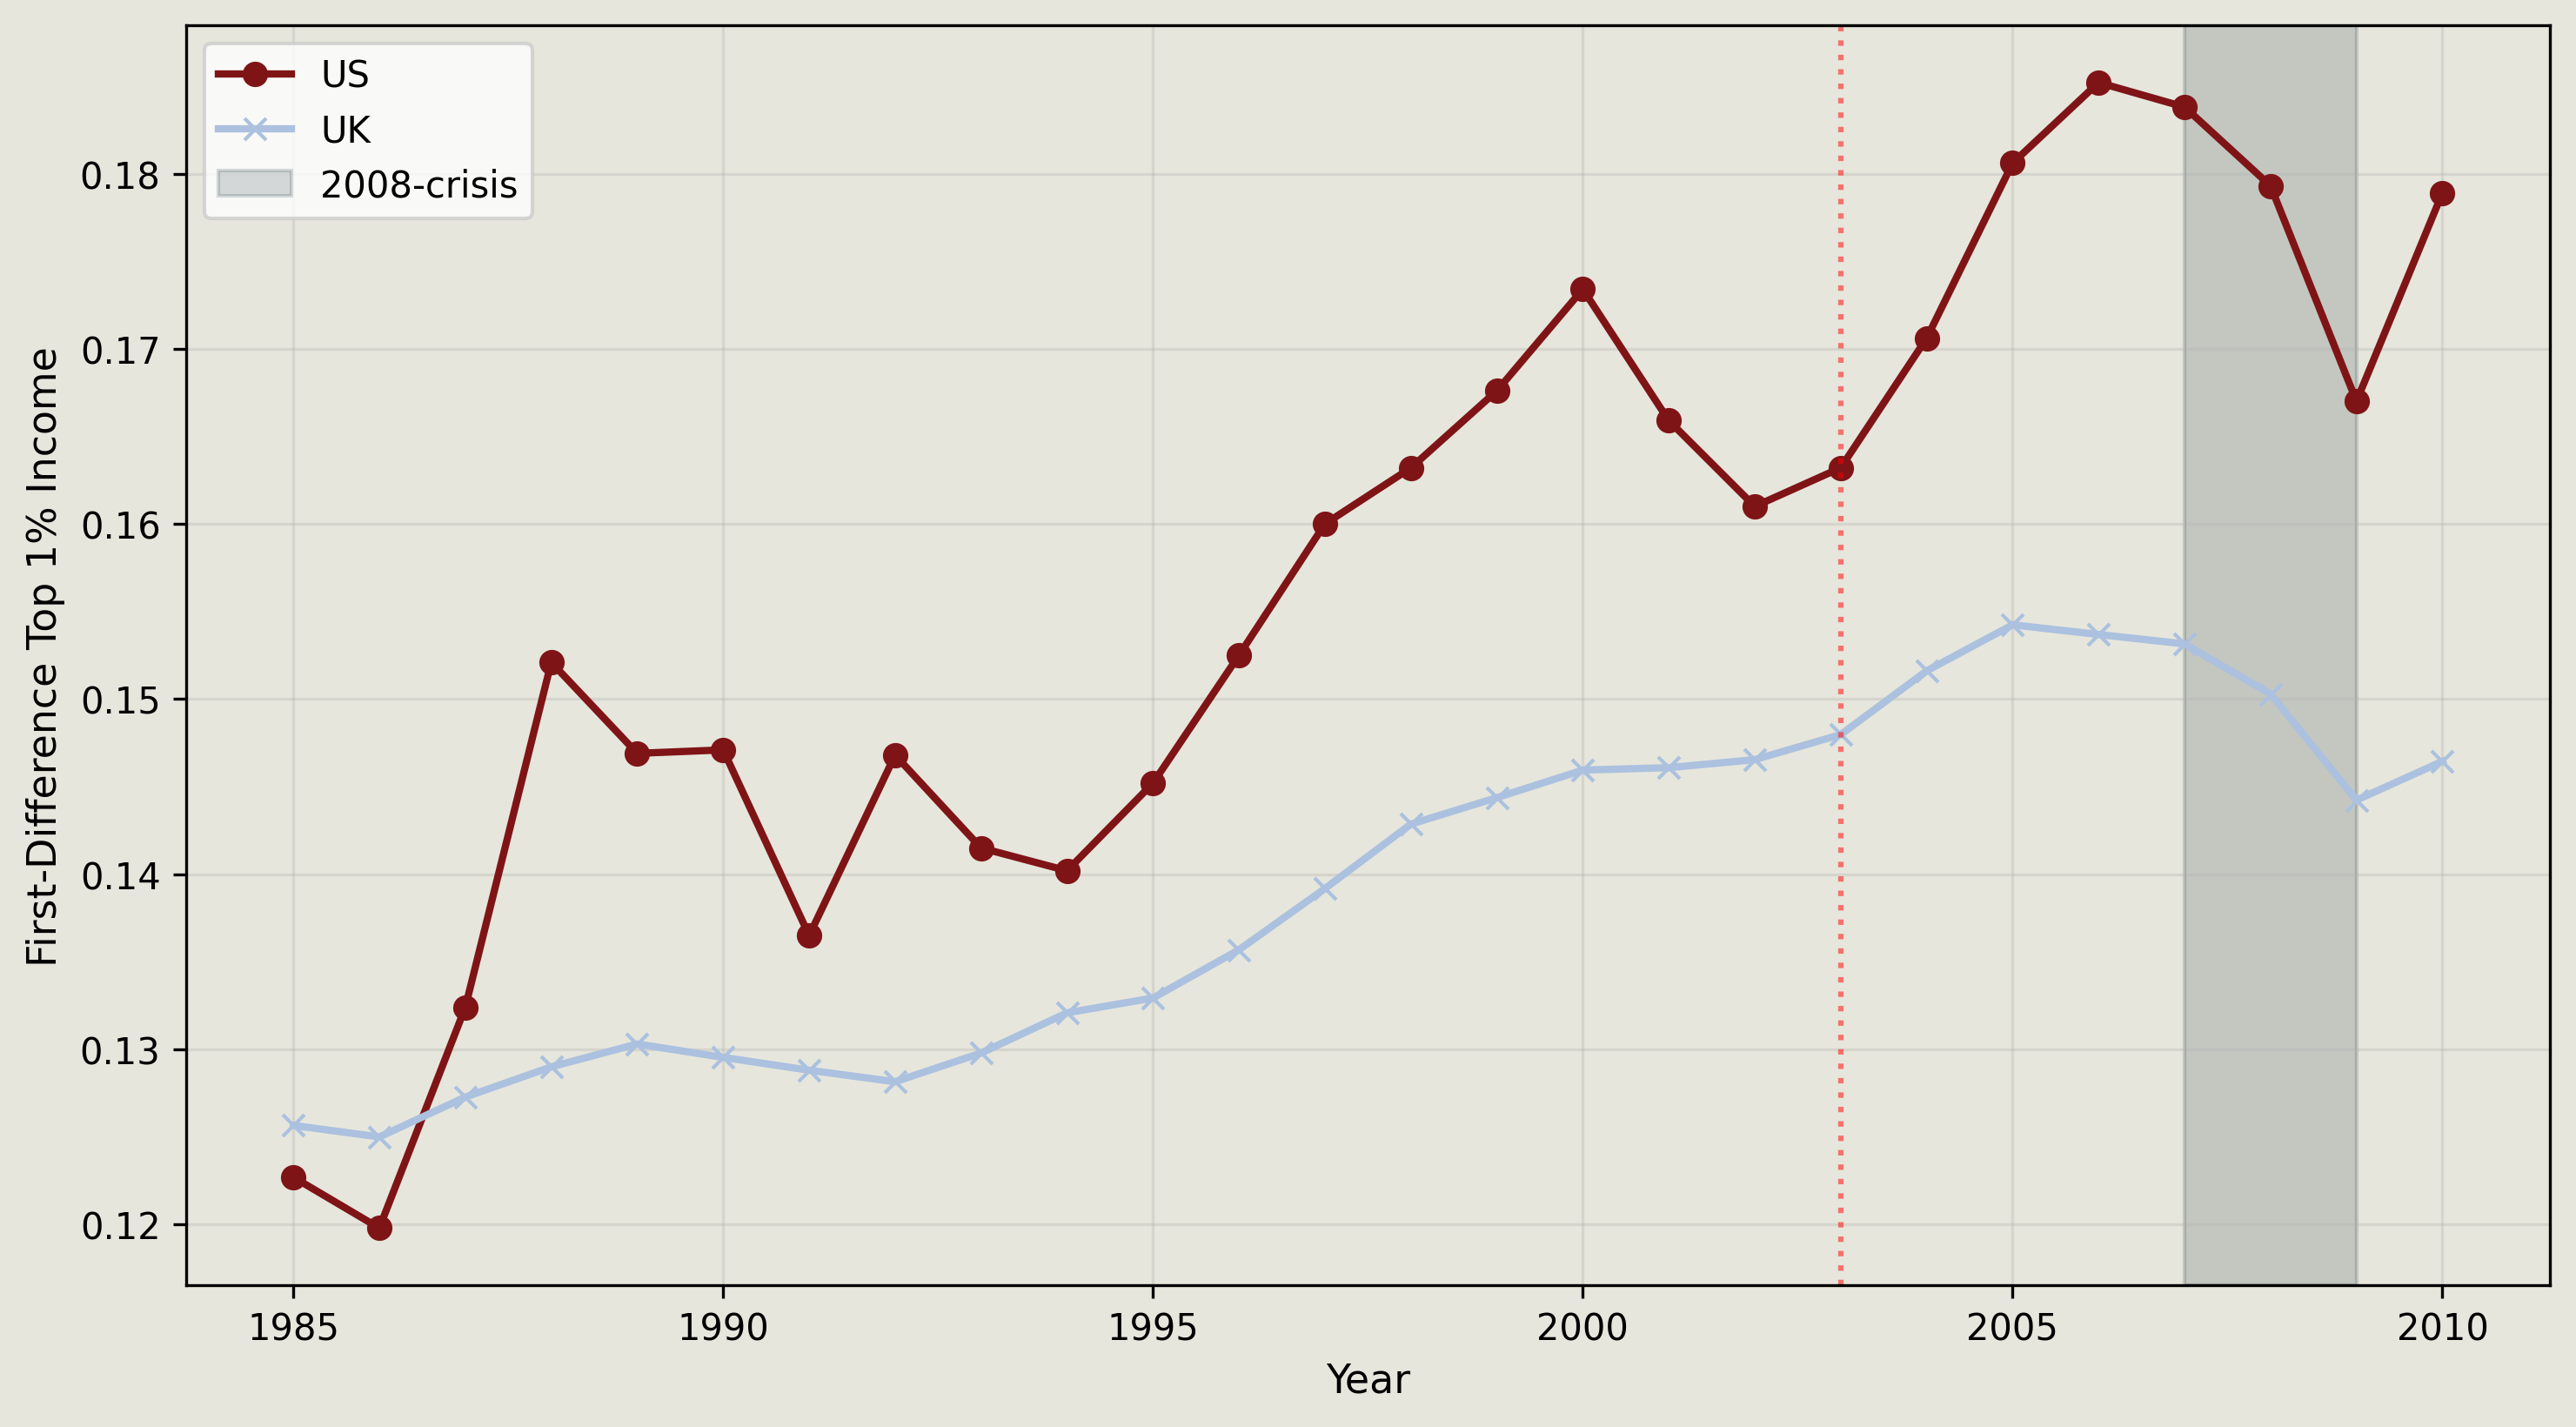

In [93]:
years = list(range(1985, 2015))

df_malka= df[(df['Year'] >= 1980) & (df['Year'] <= 2010)]
world_mean = df_malka.groupby('Year')['top1_inc'].mean()
world_median = df_malka.groupby('Year')['top1_inc'].median()
brazil_data = df_malka[df_malka['Country Name'] == 'United States'].set_index('Year')['top1_inc']
belgium_data = df_malka[df_malka['Country Name'] == 'UK'].set_index('Year')['top1_inc']

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(brazil_data.index, brazil_data.values, marker='o', label='US', color= primaryred, linewidth=2)
ax.plot(world_mean.index, world_mean.values, marker='x', label='UK', color=steelblue, linewidth=2)

plt.axvline(2003, color="red", linestyle=":",alpha=0.5)
plt.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

ax.set_xlabel('Year')
ax.set_ylabel('First-Difference Top 1% Income')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor(offwhite) 
ax.set_facecolor(offwhite) 

fig.savefig("/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/USinc.png", bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)